 ##### ======= RESULTS HEXALY SOLVER ======= ##### 
Preprocess model 100%Warning: Hexaly Optimizer is designed to run on at least 4 threads. Your system has only 2 physical cores, which may cause a significant loss in performance.
Push initial solution 100%
Model:  expressions = 11634, decisions = 76, constraints = 3, objectives = 1
Param:  time limit = 60 sec, no iteration limit

[objective direction ]:     minimize

[  0 sec,       0 itr]:        81780
[ optimality gap     ]:      100.00%
[  0 sec,    1291 itr]:            0
[ optimality gap     ]:           0%

1291 iterations performed in 0 seconds

Optimal solution: 
  obj    =            0
  gap    =           0%
  bounds =            0


C:\Users\Elfamoso\PycharmProjects\Victorien_Bigarre_Portfolio\projects\Tchoutchou\data_process.py:303: UserWarning: Glyph 128644 (\N{HIGH-SPEED TRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elfamoso\PycharmProjects\Victorien_Bigarre_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128644 (\N{HIGH-SPEED TRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


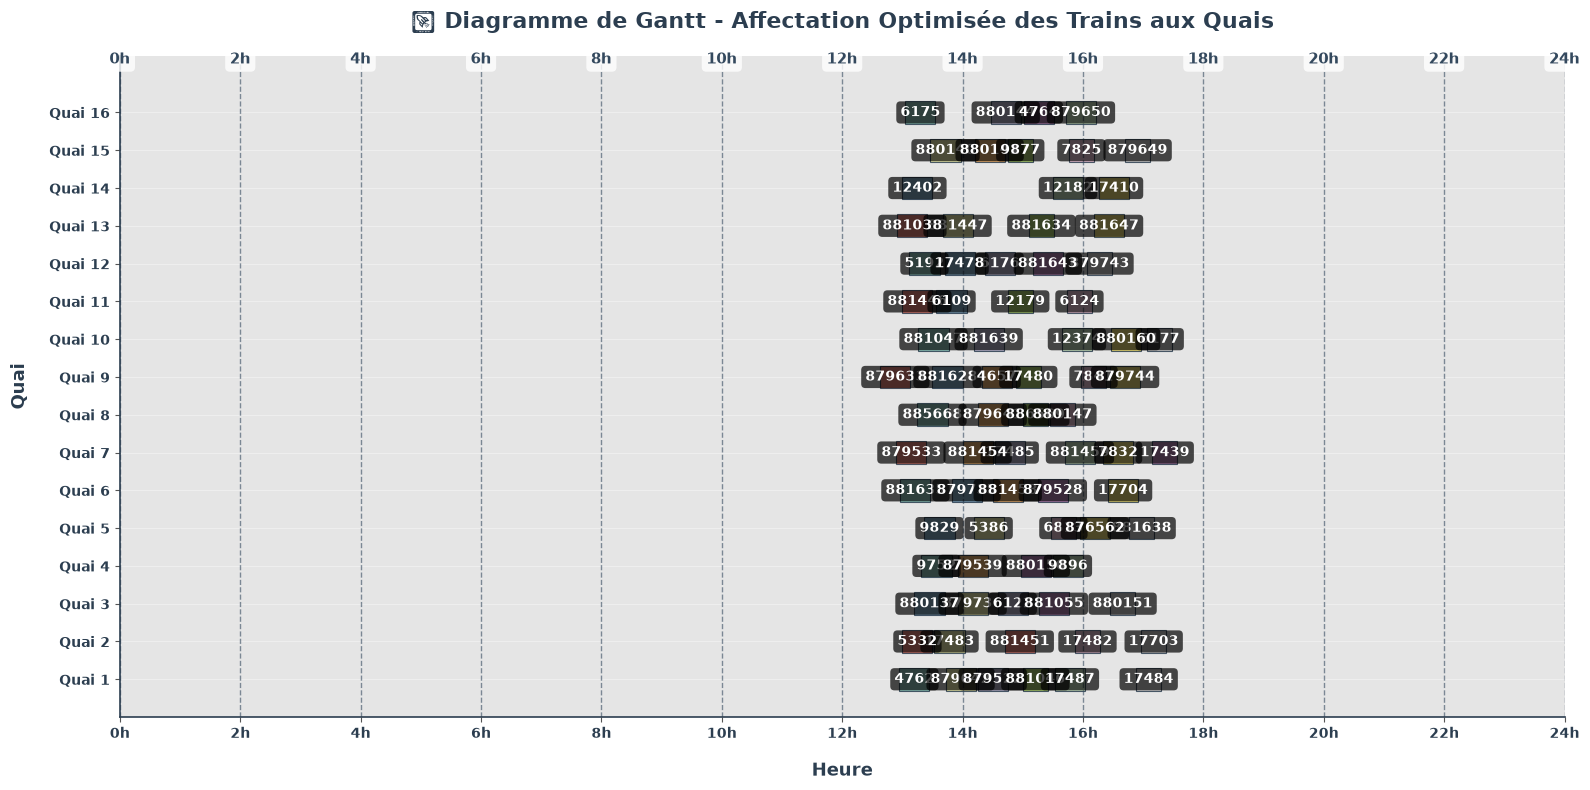

 ##### ======= RESULTS HYBRID SOLVER ======= ##### 


C:\Users\Elfamoso\PycharmProjects\Victorien_Bigarre_Portfolio\projects\Tchoutchou\data_process.py:303: UserWarning: Glyph 128644 (\N{HIGH-SPEED TRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elfamoso\PycharmProjects\Victorien_Bigarre_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128644 (\N{HIGH-SPEED TRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


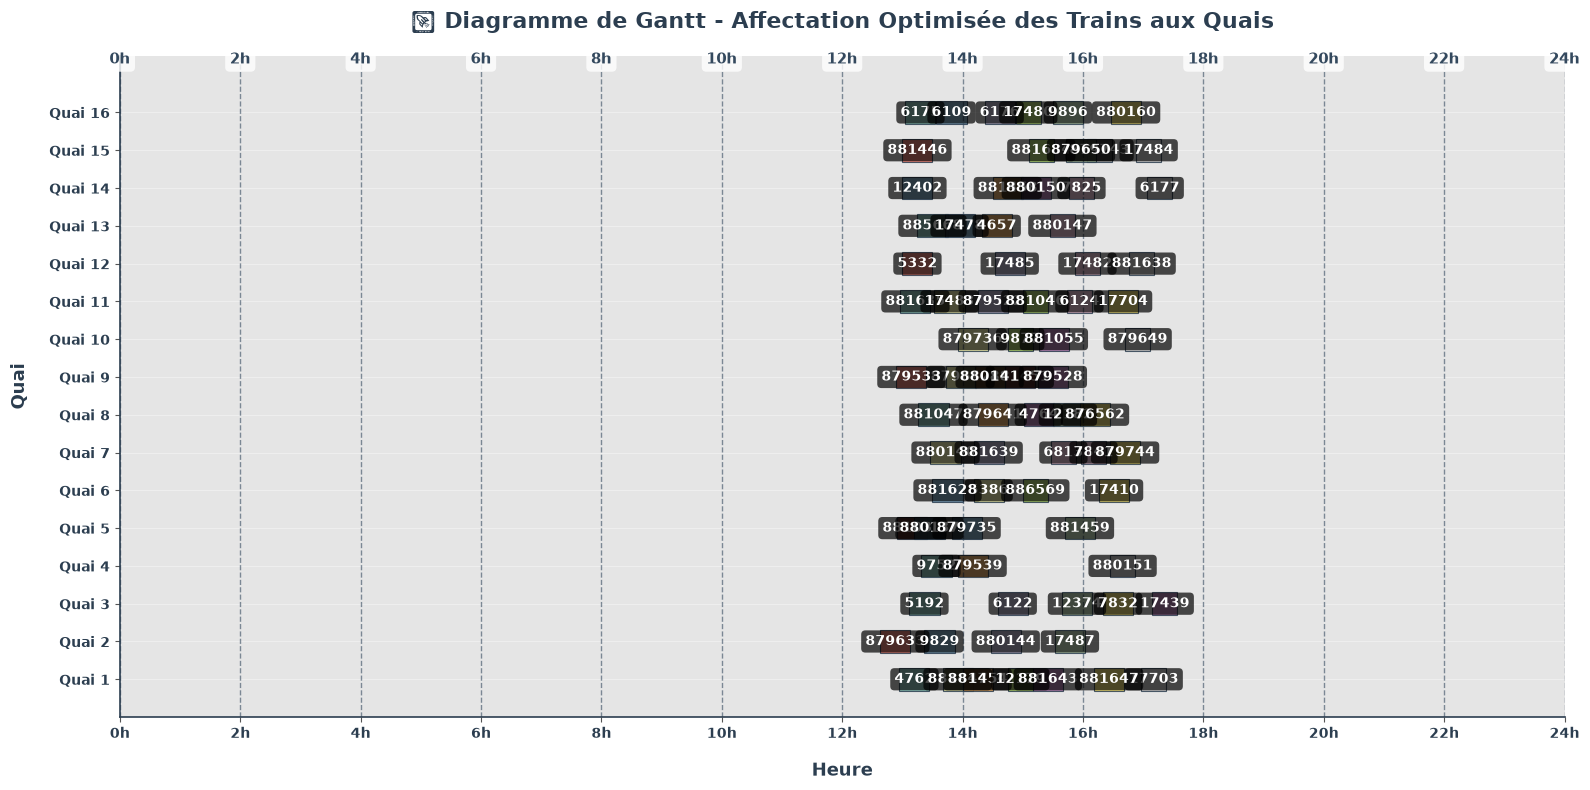

 ##### ======= SCORES ======= ##### 
Score hybride : 520
Score hexaly : 0.0


In [19]:
import pandas as pd
from data_process import TrainScheduler
from Model import HybridSolver
from Hxl_model import HexalySolver

### === DATA IMPORT
CAMINO = r"Planning_original.xlsx"
NB_QUAIS=16
PENALTY=10


# Charger les données
df = pd.read_excel(CAMINO)

# --- Solveur Hexaly ---
print(" ##### ======= RESULTS HEXALY SOLVER ======= ##### ")
hexaly = HexalySolver(df, nb_quai=NB_QUAIS, penalty=PENALTY)
hxl_solution, hxl_score = hexaly.solve(time_limit=60)

hexaly.plot_gantt(hxl_solution)

# --- Solveur Hybride (PSO+ASA) ---
print(" ##### ======= RESULTS HYBRID SOLVER ======= ##### ")
hybrid = HybridSolver(df, nb_quai=NB_QUAIS, penalty=PENALTY)
hyb_solution, hyb_score = hybrid.solve(n_particles=50, max_iter=100, asa_niter=50)
hybrid.plot_gantt(hyb_solution)

print(" ##### ======= SCORES ======= ##### ")
print(f"Score hybride : {hyb_score}")
print(f"Score hexaly : {hxl_score}")


In [10]:
results=model_hybrid.solve()

In [17]:
plot_gantt(results[0])

AttributeError: 'list' object has no attribute 'df'

<Figure size 1200x600 with 0 Axes>

In [ ]:
 plot_summary(results)

In [ ]:
##### Ca c le code à tester mais refacto

In [ ]:
from hexaly import modeler


In [14]:
import numpy as np
np.mean([840,350,660,430,940,350,960,560,570,890])

np.float64(655.0)

In [15]:
np.mean([20,20,35,19,18,18,18,19,19,18])

np.float64(20.4)

In [5]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import MolFromSmiles, GetAdjacencyMatrix

# 1. Prétraitement : SMILES -> Graphe
def smiles_to_graph(smiles):
    mol = MolFromSmiles(smiles)
    if mol is None:
        return None

    # Features des nœuds (ex : type d'atome one-hot)
    atom_types = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    x = torch.tensor([atom_types], dtype=torch.float).t()  # Transpose pour (num_atoms, num_features)

    # Matrice d'adjacence (sans self-loops)
    adj = GetAdjacencyMatrix(mol)
    edge_index = torch.tensor(list(zip(*np.where(adj > 0))), dtype=torch.long).t().contiguous()

    # Features des arêtes (ex : type de liaison)
    edge_features = []
    for bond in mol.GetBonds():
        edge_features.append([1.0 if bond.GetBondType() == bond_type else 0.0 for bond_type in [Chem.BondType.SINGLE, Chem.BondType.DOUBLE, Chem.BondType.AROMATIC]])
    edge_attr = torch.tensor(edge_features, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# 2. Définition du modèle GAT
class GAT(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super().__init__()
        self.conv1 = GATConv(num_node_features, 64, heads=4)
        self.conv2 = GATConv(64 * 4, 64, heads=4)
        self.classifier = torch.nn.Linear(64 * 4, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = global_mean_pool(x, batch=data.batch)  # Readout
        return self.classifier(x)

# 3. Entraînement
model = GAT(num_node_features=100, num_classes=2)  # 100 = taille des features (ex : one-hot pour 100 atomes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

# Boucle d'entraînement (simplifiée)
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()

NameError: name 'data' is not defined